# Create an animated figure mp4 file

In [139]:
from pathlib import Path
import os
import numpy as np
from datetime import datetime
import imageio.v2 as imageio
import earthaccess
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Video

In [137]:
%pip install imageio[ffmpeg]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 125.3 MB/s  0:00:00m0:00:01
Note: you may need to restart the kernel to use updated packages.


## Stream data

In [2]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

In [3]:
dataset_results = earthaccess.search_datasets(
    keyword="GPM IMERG", #icesat-2
    downloadable=True,
    cloud_hosted=True)

# Briefly show the search results
print(f'Dataset search returned {len(dataset_results)} results')
print('\nShowing the first result:\n', dataset_results[0].summary())

Dataset search returned 26 results

Showing the first result:
 {'short-name': 'GPM_3IMERGHH', 'concept-id': 'C2723754847-GES_DISC', 'version': '07', 'file-type': '', 'get-data': ['https://gpm1.gesdisc.eosdis.nasa.gov/data/GPM_L3/GPM_3IMERGHH.07/', 'https://search.earthdata.nasa.gov/search/granules?p=C2723754847-GES_DISC'], 'cloud-info': {'Region': 'us-west-2', 'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials', 'S3CredentialsAPIDocumentationURL': 'https://data.gesdisc.earthdata.nasa.gov/s3credentialsREADME', 'S3BucketAndObjectPrefixNames': ['s3://gesdisc-cumulus-prod-protected/GPM_L3/GPM_3IMERGHH.07/']}}


In [31]:
# Search for data
# This example retries data from ICESAT
results = earthaccess.search_data(
    short_name='GPM_3IMERGDF',#,'GPM_3IMERGDF' GPM_3IMERGHH
    bounding_box=(-124, 36, -120, 39),
    temporal=("2022-12-20", "2023-01-12"), #"2022-12-27"
    count=200 # Limits to max number of query results
)

# Briefly show the search results
print(f'Search returned {len(results)} results')
print('\nShowing the first result:\n', results[0])

# Stream the datafiles
streamed = earthaccess.open(results)

Search returned 24 results

Showing the first result:
 Collection: {'ShortName': 'GPM_3IMERGDF', 'Version': '07'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-12-20T00:00:00.000Z', 'EndingDateTime': '2022-12-20T23:59:59.999Z'}}
Size(MB): 28.00014877319336
Data: ['https://data.gesdisc.earthdata.nasa.gov/data/GPM_L3/GPM_3IMERGDF.07/2022/12/3B-DAY.MS.MRG.3IMERG.20221220-S000000-E235959.V07B.nc4']


QUEUEING TASKS | :   0%|          | 0/24 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/24 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/24 [00:00<?, ?it/s]

In [89]:
# Open the data and combine along time dimension using xr.open_mfdataset
# Extract Daily mean precipitation rate (combined microwave-IR) estimate as data array
# Set CRS, transpose dimensions to correct order, explicitly set spatial dims
precip= xr.open_mfdataset(streamed, 
                          combine='nested',
                          concat_dim='time')['precipitation']
precip = precip.rio.write_crs(4326)
precip = precip.transpose('time', 'lat', 'lon')
precip = precip.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

## Prepare data
* Clip to the California boundary

In [90]:
# Open California shapefile as geodataframe to clip to
ca_filepath = '/home/jovyan/Projects/2026-Coding-Alex/lessons/03_vector_data/data/CA_Counties.shp'
ca_counties = gpd.read_file(ca_filepath).to_crs(precip.rio.crs)
ca = ca_counties.dissolve()

# Clip precip to California area
precip_ca = precip.rio.clip(ca.geometry)

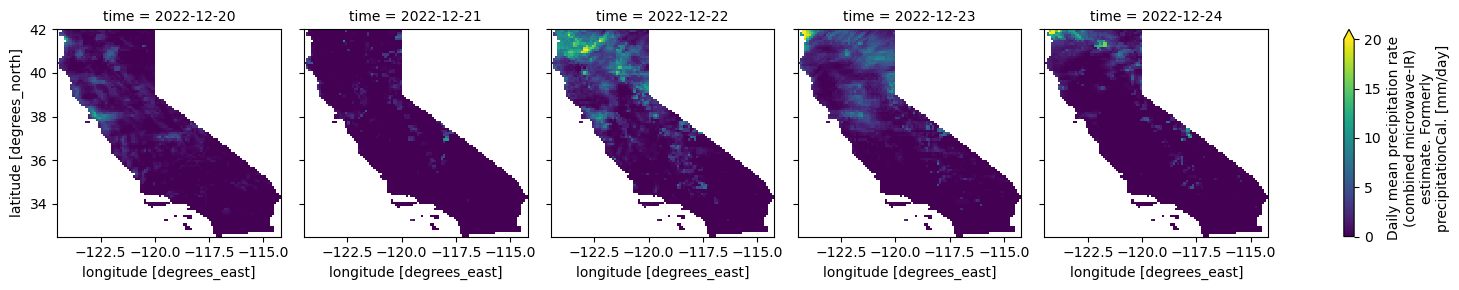

In [91]:
# Basic plot of first five dates
precip_ca.isel(time=slice(0,5)).plot(col='time', vmin=0, vmax=20)

## Create figures to animate
* Use same figure format for each timestep

In [129]:
# Create path for saving figures
figPath = Path('figs_for_animation')
figPath.mkdir(exist_ok=True)

# Set up bounds for plot area
buffer = 0.5
xmin, ymin, xmax, ymax = ca.total_bounds
x1, y1, x2, y2 = xmin-buffer, ymin-buffer, xmax+buffer, ymax+buffer

# loop over each timestep
for i, time in enumerate(precip_ca.time):

    # Get date string
    date_str = str(time.values).split('T')[0]

    # Create and save figure for each timestep
    fig,ax = plt.subplots()
    precip_ca.sel(time=time).plot(vmin=0, vmax=20, cmap='RdPu', cbar_kwargs={'extend': 'max'})
    ca.plot(ax=plt.gca(), facecolor='none', edgecolor='k')
    ax.set_title(date_str)
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)

    # Save fig with name date
    plt.savefig(figPath/(f'{date_str}.png'), bbox_inches='tight')
    plt.close(fig)
    # plt.show()

## Get the png figure files and create mp4 animation

In [134]:
# Get a list of the png figure files we created
png_files = sorted(figPath.glob("*.png"))
print(f'{len(png_files)} files to use for animation mp4. Showing first five:')
png_files[:5]

24 files to use for animation mp4. Showing first five:


[PosixPath('figs_for_animation/2022-12-20.png'),
 PosixPath('figs_for_animation/2022-12-21.png'),
 PosixPath('figs_for_animation/2022-12-22.png'),
 PosixPath('figs_for_animation/2022-12-23.png'),
 PosixPath('figs_for_animation/2022-12-24.png')]

In [138]:
# Create mp4 animation
with imageio.get_writer(figPath/"ca_precip_animated.mp4", fps=2,  format="FFMPEG") as writer:  # fps = 1 / duration fps=0.5
    for f in png_files:
        writer.append_data(imageio.imread(f))

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (537, 453) to (544, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Show the resulting animated figure in the notebook

In [140]:
Video(str(figPath / "ca_precip_animated.mp4"), embed=True)